In [1]:
%matplotlib inline
from pathlib import Path
import click
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.backends.backend_pdf
import matplotlib.style as mplstyle
import os
from datetime import datetime
import matplotlib.colors as mcolors

In [2]:
from hole_trajectory import calculate_trajectory_3d, plot_trajectory_3d, calc_binned_angles, plot_stability_comparison, calc_inclination, plot_inclination

In [3]:
mplstyle.use('fast')
plt.rcParams['lines.markersize'] = 1
plt.rcParams['font.size'] = 14
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['image.cmap'] = "viridis"
plt.rcParams['figure.max_open_warning'] = 50

In [4]:
from multi_log_reader import MultiLogReader
from preprocess import preprocess


In [11]:
#folder = "/Users/delia/Library/CloudStorage/OneDrive-SharedLibraries-NERC/BAS BigRAID Documents/Season Reports/2025/DataLog" 
folder = "/home/qgel/workdir/DataLog/"
#print(os.listdir(path = folder))
start_date="2025-07-05" #datetime.strptime(20240625,"%Y %m %d")
end_date="2025-07-08" #datetime.strptime(20240626,"%Y %m %d")
out_file = None
#out_file="paper_plots/%s_%s.pdf" % (start_date, end_date)

In [6]:
#@click.command
#@click.option("--folder", help="Folder containing BigRAID PLC logs", required=True)
#@click.option("--start", "start_date",
#              help="A start date in isoformat. Can optionally include a time as well.", required=True)
#@click.option("--end", "end_date",
#              default=None,
#              help="A end date. If not supplied, this defaults to end-of-day of the start date.")
#@click.option("--out", "out_file",
#              default=None,
#              help="Output path for the PDF. Defaults to a name based on the dates in the current folder")

In [12]:
#def plot(folder, start_date, end_date, out_file):
print(folder)
mr = MultiLogReader.find_files(folder, start_date, end_date)
df = mr.as_df()

if out_file is None:
    end_date_str = ""
    if end_date is not None:
        end_date_str = f"_{end_date}"
    out_file = Path(f"BigRAID_{start_date}{end_date_str}.pdf")
out_file = Path(out_file)
out_file = out_file.with_name(out_file.name.replace(":", "-"))
print(out_file)
#_plot(df, out_file)

/home/qgel/workdir/DataLog/
Error decoding record: err='unpack requires a buffer of 38 bytes', raw='b''', sep='b' ''
BigRAID_2025-07-05_2025-07-08.pdf


In [13]:
df = preprocess(df, run_depth_threshold=1.5)

Index(['[PLC]AUTODOWNSTOPDEPTH', '[PLC]AUTOMODE', '[PLC]AUTOSEQ',
       '[PLC]CABLESPEED', '[PLC]CABLETENSION', '[PLC]CABLETENSIONGRAMS',
       '[PLC]CYCLENUM', '[PLC]DRILLACTIVECURRENT', '[PLC]DRILLCCWMOTIONLAMP',
       '[PLC]DRILLCWMOTIONLAMP', '[PLC]DRILLFEEDBACKVEL',
       '[PLC]DRILLSTATUSWORD', '[PLC]DRILLTEMP', '[PLC]DRILLVEL',
       '[PLC]ICECONVEYOR.SETSPEED', '[PLC]IMUPITCH',
       '[PLC]IMUPITCHRATEFILTERED', '[PLC]IMUROLL', '[PLC]IMUROLLRATEFILTERED',
       '[PLC]IMUYAW', '[PLC]IMUYAWRATEFILTERED', '[PLC]SERIALCH1RXFAILCNT',
       '[PLC]SNOWBLOWER.ACTUALRPM', '[PLC]WIRESPOOLEDOUT', 'run', 'cutting',
       'cut_depth', 'weight_on_bit', 'hole_pitch', 'hole_roll'],
      dtype='str', name='tag')
[ 1.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 21.
 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36. 37. 38. 39.
 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53. 54. 55. 56. 57.
 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70. 71. 7

/tmp/ipykernel_125016/3769936168.py:101: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


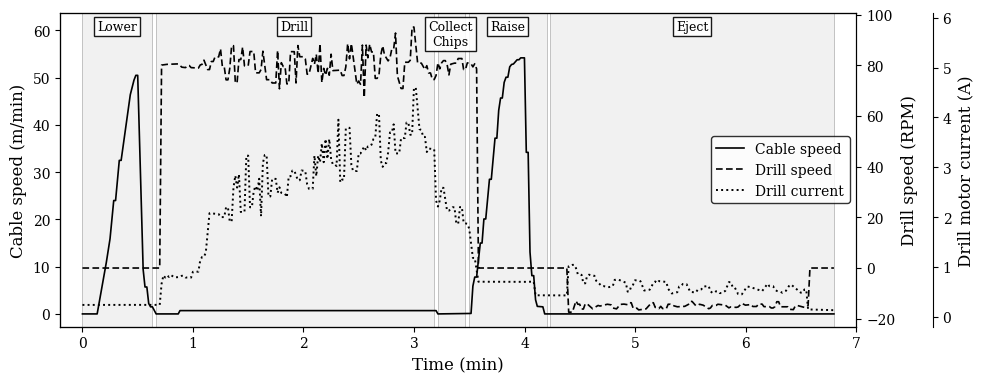

In [170]:
# Individual run plot 
print(df.keys())
print(df[df['[PLC]AUTOMODE']==1]['run'].unique())

# Publication-quality settings for this figure
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

fig, ax1 = plt.subplots(1,1)
fig.set_figwidth(10)   # Two-column width in inches (~190 mm)
fig.set_figheight(4)

# Default colours/spines to black
for spine in ax1.spines.values():
    spine.set_color('black')
ax1.tick_params(axis='both', colors='black')

run = 10
run_df = df[df['run'] == run].iloc[30:-15]
t_rel = (run_df.index - run_df.index[0]).total_seconds() / 60.0

# Create separate y-axes for each variable
ax2 = ax1.twinx()
#ax3 = ax1.twinx()
ax4 = ax1.twinx()

# Make extra spines black
for ax in [ax2,
           ax3,
           ax4]:
    ax.spines['right'].set_color('black')
    ax.tick_params(axis='y', colors='black')

# Offset the additional axes so scales don't overlap
#ax3.spines['right'].set_position(('outward', 110))
ax4.spines['right'].set_position(('outward', 55))

# Black-and-white line styles for clear differentiation
l1, = ax1.plot(t_rel, run_df['[PLC]CABLESPEED'], color='black', linestyle='-', linewidth=1.2, label='Cable speed')
l2, = ax2.plot(t_rel, run_df['[PLC]DRILLFEEDBACKVEL'], color='black', linestyle='--', linewidth=1.2, dashes=(4, 2), label='Drill speed')
#l3, = ax3.plot(t_rel, run_df['[PLC]CABLETENSION'], color='black', linestyle='-.', linewidth=1.2, label='Cable tension')
l4, = ax4.plot(t_rel, run_df['[PLC]DRILLACTIVECURRENT'].abs(), color='black', linestyle=':', linewidth=1.4, label='Drill current')

# Labels in black
ax1.set_ylabel('Cable speed (m/min)', color='black')
ax2.set_ylabel('Drill speed (RPM)', color='black')
#ax3.set_ylabel('Cable tension (kg)', color='black')
ax4.set_ylabel('Drill motor current (A)', color='black')

ax1.tick_params(axis='y', labelcolor='black')
ax2.tick_params(axis='y', labelcolor='black')
#ax3.tick_params(axis='y', labelcolor='black')
ax4.tick_params(axis='y', labelcolor='black')

# Combined legend inside plot frame
lines = [l1,
         l2,
         #l3,
         l4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', frameon=True, fancybox=True, edgecolor='black')

# Extend the top of the primary y-axis so region labels sit clear of the data
y_min, y_max = ax1.get_ylim()
ax1.set_ylim(y_min, y_max * 1.12)

ax4.set_ylim(-0.2, 6.1)
ax4.set_yticks(range(0, 7))

# Mark regions by time with labels (grayscale shading, black text)
# Provide regions as list of (start_idx, end_idx, label)
annotated_regions = [
    # (100, 500, 'Cutting phase'),
    # (600, 900, 'Raising'),
    (0, 38, "Lower"),
    (40, 191, "Drill"),
    (193, 208, "Collect\nChips"),
    (210, 252, "Raise"),
  #  (284, 300, "Traverse"),
    (254, 408, "Eject"),
]

for start_idx, end_idx, label in annotated_regions:
    start = t_rel[start_idx]
    end = t_rel[end_idx]
    ax1.axvspan(start, end, facecolor='lightgray', alpha=0.3, edgecolor='black', linestyle='-', linewidth=0.5)
    mid_idx = (start_idx + end_idx) // 2
    mid = t_rel[mid_idx]
    y_pos = max(ax1.get_ylim()) * 0.975
    ax1.text(mid, y_pos, label, ha='center', va='top', fontsize=9, color='black',
             bbox=dict(boxstyle='square,pad=0.25', facecolor='white', edgecolor='black', alpha=0.9))

ax1.set_xlabel('Time (min)')
#ax1.set_title(f'Example 2025 Drill Run (Automated)')
ax1.margins(x=0.03)
fig.tight_layout()

In [171]:
fig.savefig("/tmp/individual_run.pdf")

/tmp/ipykernel_125016/792318929.py:33: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


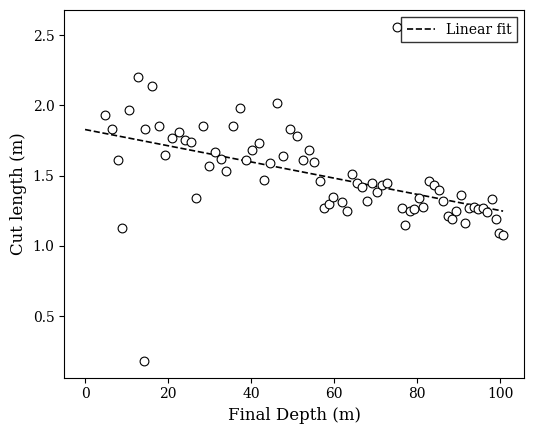

In [180]:
# Cut depth by depth plot (black-and-white, journal style)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12

fig = plt.figure(figsize=(5.5, 4.5))
ax = plt.subplot()

for spine in ax.spines.values():
    spine.set_color('black')
ax.tick_params(axis='both', colors='black')

run_cut_depth = df['cut_depth'].groupby(df['run']).max()
run_depth = df['[PLC]WIRESPOOLEDOUT'].groupby(df['run']).max()
run_auto_mode = df['[PLC]AUTOMODE'].groupby(df['run']).any()
labels = ['_A' if a else '_M' for a in run_auto_mode.values]

# Grayscale markers with black edge for professional B/W reproduction
ax.scatter(run_depth, run_cut_depth.values, color='white', edgecolor='black', linewidth=0.8, s=40, zorder=3)

# Plot the average
#ax.axhline(np.mean(run_cut_depth.values), 0, max(run_depth))

# Regression line in black
coeff = np.polyfit(run_depth, run_cut_depth.values, 1)
fit_fn = np.poly1d(coeff)
ax.plot([0, max(run_depth)], [fit_fn(0), fit_fn(max(run_depth))], 'k--', linewidth=1.2, label='Linear fit')

ax.set_ylabel("Cut length (m)")
ax.set_xlabel("Final Depth (m)")
ax.legend(loc='best', frameon=True, fancybox=False, edgecolor='black')
fig.tight_layout()

In [182]:
import json

hole_times = "2025-Drill-Log.json"

with Path(hole_times).open("r") as f:
    hole_time_data = json.load(f)

dataframes = []
for hole_data in hole_time_data:
    try:
        number, site, hole, t_start, t_end, geoloc = (
            hole_data['number'],
            hole_data['site'], hole_data['hole'],
            hole_data['start'], hole_data.get('end'),
            hole_data.get('geoloc', "")
        )
    except KeyError as e:
        print(f"Error. Malformed hole times json. Missing: {e} in {hole_data}")
        continue

    print(f"Reading data for hole {number}-{site}-{hole}")
    cached_df = MultiLogReader.find_files(folder, t_start, t_end).as_df()
    cached_df = preprocess(cached_df)
    cached_df['number'] = number
    cached_df['site'] = site
    cached_df['hole'] = hole
    cached_df['geoloc'] = geoloc

    cached_df['hole_duration'] = np.arange(0, cached_df.shape[0])

    dataframes.append(cached_df)

mdf = pd.concat(dataframes)

Reading data for hole 2-25-1
Reading data for hole 3-25-2
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
Error decoding record timestamp: time_str=b'\x00\x00\x00\x00\x

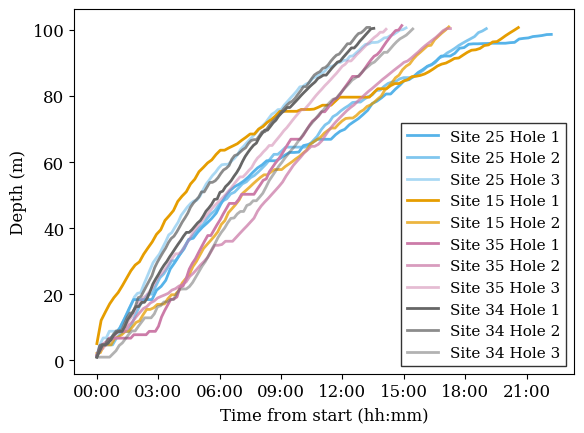

In [219]:
# multi hole duration plot (black-and-white, journal style)

from matplotlib.dates import DateFormatter


plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12

hole_groups = mdf.groupby(['number','site', 'hole'])

fig = plt.figure(figsize=(6, 4.5))
ax = fig.subplots()

for spine in ax.spines.values():
    spine.set_color('black')
ax.tick_params(axis='both', colors='black')

# Assign three shades of the same base color per site
sites = sorted(mdf['site'].unique())
#base_colors = plt.cm.tab10.colors[:len(sites)]
###595959
base_colors = ((0, 0x6B/0xFF, 0xA4/0xFF, 1.0),
               (0xFF/0xFF, 0x80/0xFF, 0x0E/0xFF, 1.0),
               (0xAB/0xFF, 0xAB/0xFF, 0xAB/0xFF, 1.0),
               (0x59/0xFF, 0x59/0xFF, 0x59/0xFF, 1.0),
)

base_colors = ((0xe6/0xff, 0x9d/0xFF, 0x00/0xFF, 1.0),
               (0x56/0xFF, 0xb3/0xFF, 0xe9/0xFF, 1.0),
               #(0x00/0xFF, 0x9e/0xFF, 0x74/0xFF, 1.0),
               (0.4,0.4,0.4,1.0),
               #(0xf0/0xFF, 0xe4/0xFF, 0x42/0xFF, 1.0),
               (0xcc/0xff, 0x7b/0xff, 0xa8/0xff, 1.0)
)
site_shades = {}
for s, base in zip(sites, base_colors):
    # Generate three shades: 100%, 65%, and 35% of the base color
    site_shades[s] = [
        (base[0],  base[1],  base[2], 1.0),
        (base[0],  base[1],  base[2], 0.75),
        (base[0],  base[1],  base[2], 0.5),
    ]
    # site_shades[s] = [
    #     (base[0]*1.0,  base[1]*1.0,  base[2]*1.0, 1.0),
    #     (base[0]*0.65, base[1]*0.65, base[2]*0.65, 1.0),
    #     (base[0]*0.35, base[1]*0.35, base[2]*0.35, 1.0),
    # ]
# Hole -> shade index within a site (1->0, 2->1, 3->2, 4->0, ...)

for (number, site, hole), idx in hole_groups.groups.items():
    data = mdf.loc[idx, ['[PLC]WIRESPOOLEDOUT', 'hole_duration']].cummax()
    # Choose 100 evenly spaced points and subsample the data
    subset_idx = np.round(np.linspace(0, data.shape[0]-1, 100)).astype(int)
    subsample = data.iloc[subset_idx]

    shade_idx = (int(hole) - 1) % 3
    color = site_shades[site][shade_idx]
    ax.plot(
        pd.to_datetime(subsample['hole_duration'], unit='s'),
        subsample['[PLC]WIRESPOOLEDOUT'],
        color=color,
        linewidth=2,
        label=f"Site {site} Hole {hole}",
    )

formatter = DateFormatter("%H:%M")
ax.xaxis.set_major_formatter(formatter)

ax.set_xlabel("Time from start (hh:mm)")
ax.set_ylabel("Depth (m)")
ax.legend(loc='best', frameon=True, fancybox=False, edgecolor='black', fontsize=11)
fig.tight_layout()

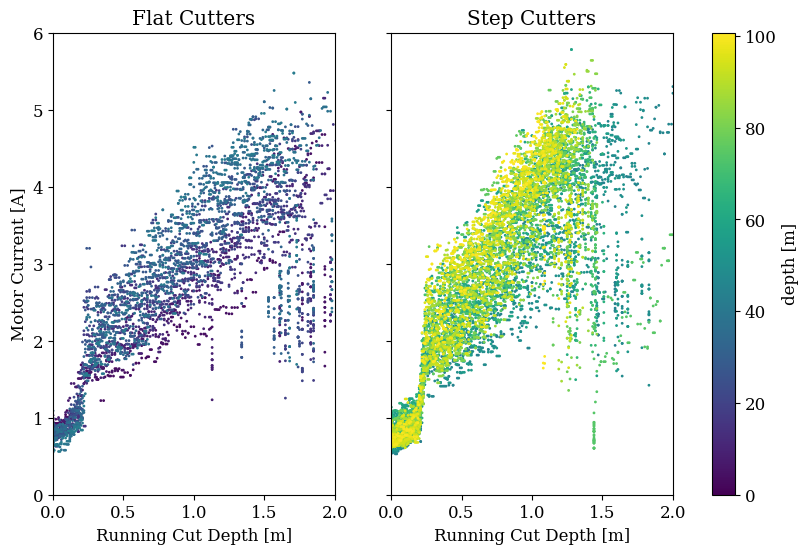

In [208]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
fig.set_figwidth(10)
fig.set_figheight(6)

fig.suptitle('')
global_min = np.min(df["[PLC]WIRESPOOLEDOUT"])
global_max = np.max(df["[PLC]WIRESPOOLEDOUT"])
norm = mcolors.Normalize(vmin=global_min, vmax=global_max)

img0=df[(df["cutting"] == 1) & (df["[PLC]WIRESPOOLEDOUT"] < 42)].plot.scatter(x="cut_depth", y="[PLC]DRILLACTIVECURRENT", c="[PLC]WIRESPOOLEDOUT", s =1, rasterized=True, cmap="viridis", ax = ax1, norm = norm, colorbar=False)
#plt.title("Motor Current vs Running Cut Depth")
ax1.set_xlabel("Running Cut Depth [m]")
ax1.set_ylabel("Motor Current [A]")
ax1.set_title("Flat Cutters")
ax1.set_ylim(0,6)
ax1.set_xlim(0,2)

img1=df[(df["cutting"] == 1) & (df["[PLC]WIRESPOOLEDOUT"] >= 42)].plot.scatter(x="cut_depth", y="[PLC]DRILLACTIVECURRENT", c="[PLC]WIRESPOOLEDOUT", s =1, rasterized=True, cmap="viridis", ax = ax2, norm = norm, colorbar=False)

#plt.title("Motor Current vs Running Cut Depth")
ax2.set_xlabel("Running Cut Depth [m]")
ax2.set_ylabel("Motor Current [A]")
ax2.set_title("Step Cutters")
ax2.set_ylim(0,6)
ax2.set_xlim(0,2)


fig.colorbar(img0.collections[0],ax=[ax1,ax2], shrink=1, location='right', label= 'depth [m]')
plt.show()
fig.savefig("flat_vs_step_cutters_motor_current.pdf")


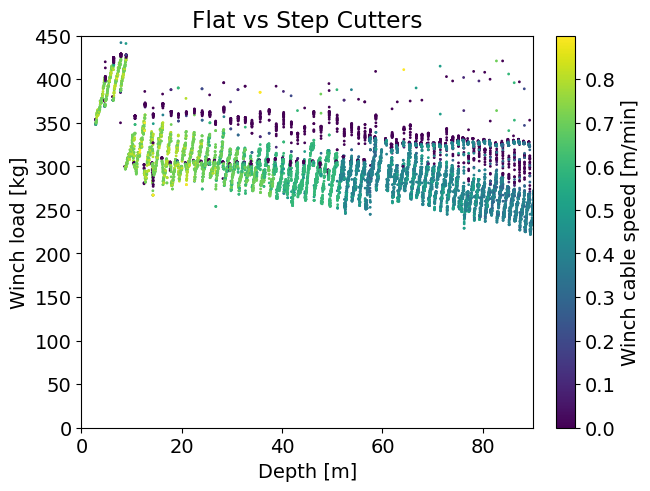

In [16]:
fig, ax = plt.subplots(1, 1)
#fig2.set_figwidth(5)
#fig2.set_figheight(6)
img=df[(df["cutting"] == 1)].plot.scatter(x="[PLC]WIRESPOOLEDOUT", y="[PLC]CABLETENSION", c="[PLC]CABLESPEED", s =1, rasterized=True, cmap="viridis", ax = ax, colorbar = False)#norm = norm)
ax.set_xlabel("Depth [m]")
ax.set_ylabel("Winch load [kg]")
ax.set_title("Flat vs Step Cutters")
ax.set_ylim(0,450)
ax.set_xlim(0,90)
fig.colorbar(img.collections[0],ax=ax, shrink=1, location='right', label= 'Winch cable speed [m/min]')
fig.savefig("flat_vs_step_cutters_winch_load.pdf")


In [ ]:
# everything below here for reference
def _plot(df, out_path):
    # Add additional calculated columns to the data
    df = preprocess(df, run_depth_threshold=1.5)
    figures_start_idx = plt.gcf().number + 1

    df[df["cutting"] == 1].plot.scatter(x="cut_depth", y="[PLC]DRILLACTIVECURRENT", c="run", s =1, rasterized=True, cmap="viridis")
    #plt.title("Motor Current vs Running Cut Depth")
    plt.xlabel("Running Cut Depth [m]")
    plt.ylabel("Motor Current [A]")
    plt.ylim(0,6.5)
    plt.xlim(0,2.6)

    df[df["cutting"] == 1].plot.scatter(x="[PLC]WIRESPOOLEDOUT", y="[PLC]CABLETENSION", c="run", s =1, rasterized=True, cmap="viridis")
    #plt.title("Cable Tension vs Depth")
    plt.ylabel("Cable Tension [kg]")
    plt.xlabel("Depth [m]")
    plt.ylim(120,480)
    plt.xlabel("Depth [m]")
    plt.xlim(0,105)

    df[df["cutting"] == 1].plot.scatter(x="run", y="cut_depth",s =1, rasterized=True, cmap="viridis")
    #plt.title("Running Cut Depth per run")
    plt.ylabel("Running Cut Depth [m]")
    plt.xlabel("Run")
    plt.ylim(0,2.6)
    
    df[df["cutting"] == 1].plot.scatter(x="[PLC]WIRESPOOLEDOUT", y="cut_depth",s =1, rasterized=True, cmap="viridis")
    #plt.title("Running Cut Depth per run")
    plt.ylabel("Running Cut Depth [m]")
    plt.xlabel("Depth [m]")
    plt.ylim(0,2.6)


    df[df["cutting"] == 1].plot.scatter(x="cut_depth", y="[PLC]CABLETENSION", c="run", s =1, rasterized=True, cmap="viridis")
    #plt.title("Cable Tension vs Running Cut Depth")
    plt.ylabel("Cable Tension [kg]")
    plt.xlabel("Running Cut Depth [m]")
    plt.ylim(120,480)
    plt.xlim(0,2.6)

    df[df["cutting"] == 1].plot.scatter(x="cut_depth", y="[PLC]CABLETENSION", c="[PLC]CABLESPEED",s =1, rasterized=True, cmap="viridis")
    #plt.title("Cable Tension vs Running Cut Depth")
    plt.ylabel("Cable Tension [kg]")
    plt.xlabel("Running Cut Depth [m]")
    plt.ylim(120,480)
    plt.xlim(0,2.6)

    df[(df["cutting"] == 1)].plot.scatter(x="cut_depth", y="weight_on_bit", c="run",s =1, rasterized=True, cmap="viridis")
    #plt.title("Estimated Weight on Bit vs Running Cut Depth")
    plt.ylabel("Weight On Bit [kg]")
    plt.xlabel("Running Cut Depth [m]")
    plt.xlim(0,2.6)
    plt.ylim(0,180)

    df[df["cutting"] == 1].plot.scatter(x="[PLC]WIRESPOOLEDOUT", y="[PLC]DRILLFEEDBACKVEL", c="[PLC]CABLESPEED",s =1, rasterized=True, cmap="viridis")
    #plt.title("RPM vs Running Cut Depth")
    plt.ylabel("Motor speed [RPM]")
    plt.xlabel("Depth [m]")
    plt.ylim(60,140)
    plt.xlim(0,100)

    df[df["cutting"] == 1].plot.scatter(x="[PLC]WIRESPOOLEDOUT", y="[PLC]CABLESPEED", c="[PLC]DRILLFEEDBACKVEL",s =1, rasterized=True, cmap="viridis")
    #plt.title("RPM vs Running Cut Depth")
    plt.ylabel("Rate of penetration [m/min]")
    plt.xlabel("Depth [m]")
    plt.ylim(0,1)
    plt.xlim(0,100)

    def group_duration(x):
        diff = x.diff()
        return diff[diff < np.timedelta64(10, 's')].sum()
    total = df[df["run"] > 0].index.to_series().groupby(df["run"]).agg(np.ptp).dt.total_seconds().rename("total")
    cutting = df[df["cutting"] == 1].index.to_series().groupby(df["run"]).agg(np.ptp).dt.total_seconds().rename("cutting")
    moving = df[df["[PLC]CABLESPEED"] > 2].index.to_series().groupby(df["run"]).agg(group_duration).dt.total_seconds().rename("moving")
    ejecting = df[df["[PLC]DRILLFEEDBACKVEL"] < -5].index.to_series().groupby(df["run"]).agg(np.ptp).dt.total_seconds().rename("ejecting")
    if "[PLC]ICECONVEYOR.SETSPEED" in df.columns:
        snowblower_travel = df[df['[PLC]ICECONVEYOR.SETSPEED'].abs() > 1].index.to_series().groupby(df["run"]).agg(group_duration).dt.total_seconds().rename("snowblower_travel")
    else:
        snowblower_travel = pd.Series(np.zeros(cutting.shape)).rename("snowblower_travel")
    grps = pd.concat([total, moving, cutting, ejecting, snowblower_travel], axis=1).fillna(0.0)
    
    fig = plt.figure()
    ax = plt.subplot()
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    ax.bar(grps.index, grps['total'], color=colors[0], label="Total")
    ax.bar(grps.index, grps['cutting'], color=colors[1], label="Cutting")
    ax.bar(grps.index, grps['snowblower_travel'], color=colors[2], label="Snowblower Travel", bottom=grps['cutting'])
    ax.bar(grps.index, grps['ejecting'], color=colors[3], label="Ejecting", bottom=grps['cutting'] + grps['snowblower_travel'])
    ax.bar(grps.index, grps['moving'], color=colors[4], label="Moving", bottom=grps['cutting'] + grps['snowblower_travel'] + grps["ejecting"])
    ax.legend()
    #ax.set_title("Time per Run")
    ax.set_ylabel("Time [s]")
    ax.set_xlabel("Run")

    fig = plt.figure()
    ax = plt.subplot()
    run_cut_depth = df['cut_depth'].groupby(df['run']).max()
    run_cut_speed = (run_cut_depth / total) * 60 * 60
    run_auto_mode = df['[PLC]AUTOMODE'].groupby(df['run']).any()
    colors = ['tab:orange' if a else 'tab:blue' for a in run_auto_mode.values]
    labels = ['_A' if a else '_M' for a in run_auto_mode.values]
    if "_A" in labels:
        if (idx := labels.index("_A")) >= 0:
            labels[idx] = "Auto"
    if "_M" in labels:
        if (idx := labels.index("_M")) >= 0:
            labels[idx] = "Manual"
    ax.bar(run_cut_speed.index, run_cut_speed.values, color=colors, label=labels)

    # Plot the average
    ax.axhline(np.mean(run_cut_speed.values), 0, max(run_cut_speed.index))

    # Plot a regression line
    coeff = np.polyfit(run_cut_speed.index, run_cut_speed.values, 1)
    fit_fn = np.poly1d(coeff)
    ax.plot([0, max(run_cut_speed.index)], [fit_fn(0), fit_fn(max(run_cut_speed.index))], 'r--')

    fig.suptitle("Drilling Performance")
    ax.set_title("Cut length / Total time for the run")
    ax.set_ylabel("Drilling Performance [m/h]")
    ax.set_xlabel("Run")
    ax.legend(title="Mode")

    #fig, axes = plt.subplots(1, 3)
    display_max = 0
    for i, k in enumerate(["[PLC]IMUYAW","[PLC]IMUPITCH", "[PLC]IMUROLL"]):
        fig = plt.figure()
        ax = plt.subplot()
        d = df[(df["[PLC]WIRESPOOLEDOUT"] > 2)]
        # subtract the mean when the drill is hanging freely above the hole
        #zero_offset = df[(df["[PLC]WIRESPOOLEDOUT"] < 1) & (df["[PLC]CABLESPEED"].abs() < 0.1) & (df["[PLC]DRILLFEEDBACKVEL"].abs() < 0.1) & (df[k].abs() < 5.0)][k].mean()

        vals = d[k]# - zero_offset
        display_max = max(vals.abs().quantile(0.99), display_max)
        depth_max = df['[PLC]WIRESPOOLEDOUT'].max()
        #print(i,k, vals.values)
        if k=="[PLC]IMUYAW":
            xmin = -180
            xmax = 180
        elif  k=="[PLC]IMUROLL":
            xmin = -2
            xmax = 2
        elif  k=="[PLC]IMUPITCH":
            xmin = -2
            xmax = 2
        H, xedges, yedges = np.histogram2d(d["[PLC]WIRESPOOLEDOUT"], vals, bins=[int(depth_max/2), 50], range=[[0, depth_max], [xmin, xmax]])
        H_norm_rows = H / H.max(axis=1, keepdims=True)
        H_norm_rows = np.nan_to_num(H_norm_rows)
        ax.pcolormesh(yedges, xedges, H_norm_rows, rasterized=True, cmap="viridis")
        ax.set_title(k)
        ax.set_xlim(xmin, xmax)
        #ax.set_xlim(-display_max, display_max)
        #fig.title("Angle per Depth")
        ax.set_ylabel("Wire spooled out [m]")
        ax.set_xlabel("Angle [deg]")    
    yaw_rad = np.deg2rad(d["[PLC]IMUYAW"].values)
    pitch_rad= np.deg2rad(d["[PLC]IMUPITCH"].values)
    roll_rad = np.deg2rad(d["[PLC]IMUROLL"].values)

    fig, axes = plt.subplots(1, 2)
    display_max = 0
    for i, k in enumerate(["[PLC]IMUPITCH", "[PLC]IMUROLL"]):
        d = df[(df[k].abs() < 2) & (df["[PLC]WIRESPOOLEDOUT"] > 2)]
        # subtract the mean when the drill is hanging freely above the hole
        zero_offset = df[(df["[PLC]WIRESPOOLEDOUT"] < 1) & (df["[PLC]CABLESPEED"].abs() < 0.1) & (df["[PLC]DRILLFEEDBACKVEL"].abs() < 0.1) & (df[k].abs() < 5.0)][k].mean()

        vals = d[k] - zero_offset
        display_max = max(vals.abs().quantile(0.99), display_max)
        depth_max = df['[PLC]WIRESPOOLEDOUT'].max()
        H, xedges, yedges = np.histogram2d(d["[PLC]WIRESPOOLEDOUT"], d[k] - zero_offset, bins=[int(depth_max/2), 50], range=[[0, depth_max], [-2, 2]])
        H_norm_rows = H / H.max(axis=1, keepdims=True)
        H_norm_rows = np.nan_to_num(H_norm_rows)
        axes[i].pcolormesh(yedges, xedges, H_norm_rows, cmap="viridis")
        axes[i].set_title(k)
    for ax in axes:
        ax.set_xlim(-display_max, display_max)
    fig.suptitle("Angle per Depth")
    fig.supylabel("Wire spooled out [m]")
    fig.supxlabel("Angle [deg]")

    fig, axes = plt.subplots(1, 2)
    display_max = 0
    for i, k in enumerate(["hole_pitch", "hole_roll"]):
        d = df[(df[k].abs() < 2) & (df["[PLC]WIRESPOOLEDOUT"] > 2)]
        # subtract the mean when the drill is hanging freely above the hole
        zero_offset = df[(df["[PLC]WIRESPOOLEDOUT"] < 1) & (df["[PLC]CABLESPEED"].abs() < 0.1) & (df["[PLC]DRILLFEEDBACKVEL"].abs() < 0.1) & (df[k].abs() < 5.0)][k].mean()

        vals = d[k] - zero_offset
        display_max = max(vals.abs().quantile(0.99), display_max)
        depth_max = df['[PLC]WIRESPOOLEDOUT'].max()
        H, xedges, yedges = np.histogram2d(d["[PLC]WIRESPOOLEDOUT"], d[k] - zero_offset, bins=[int(depth_max/2), 50], range=[[0, depth_max], [-2, 2]])
        H_norm_rows = H / H.max(axis=1, keepdims=True)
        H_norm_rows = np.nan_to_num(H_norm_rows)
        axes[i].pcolormesh(yedges, xedges, H_norm_rows, cmap="viridis")

        # Plot a regression line
        coeff = np.polyfit(d["[PLC]WIRESPOOLEDOUT"].values, vals.values, 1)
        fit_fn = np.poly1d(coeff)
        axes[i].plot([fit_fn(0), fit_fn(depth_max)], [0, depth_max], 'r--')

        axes[i].set_title(k)
    for ax in axes:
        ax.set_xlim(-display_max, display_max)
    fig.suptitle("Angle per Depth, normalized using IMU Yaw")
    fig.supylabel("Wire spooled out [m]")
    fig.supxlabel("Angle [deg]")

    # Plot a 3D trajectory for the hole
    dz = 1.0
    mean_angles_x, std_dev_angles_x, angle_bin_sizes = calc_binned_angles(df, "hole_pitch", dz=dz)
    mean_angles_y, std_dev_angles_y, _= calc_binned_angles(df, "hole_roll", dz=dz)

    z_coords, x_mean, x_std, y_mean, y_std = calculate_trajectory_3d(
        mean_angles_x, std_dev_angles_x,
        mean_angles_y, std_dev_angles_y,
        dz=dz
    )
    plot_trajectory_3d(z_coords, x_mean, x_std, y_mean, y_std)

    # Do some stability checks on the trajectory.
    def _plot_stability(df_comp, subtitle):
        comp_mean_x, comp_std_x, _ = calc_binned_angles(df_comp, "hole_pitch", dz=dz)
        comp_mean_y, comp_std_y, _ = calc_binned_angles(df_comp, "hole_roll", dz=dz)

        comp_z_coords, comp_x_mean, comp_x_std, comp_y_mean, comp_y_std = calculate_trajectory_3d(
            comp_mean_x, comp_std_x,
            comp_mean_y, comp_std_y
        )

        plot_stability_comparison(z_coords, x_mean, x_std, y_mean, y_std, comp_z_coords, comp_x_mean, comp_y_mean, subtitle)

    ## Take only angles when the drill is moving up
    df_down = df[(df['[PLC]WIRESPOOLEDOUT'].diff() > 0) | (df["[PLC]CABLESPEED"].abs() < 0.1)].dropna()
    _plot_stability(df_down, "Downgoing subset")

    ## When the drill is moving up
    df_up = df[(df['[PLC]WIRESPOOLEDOUT'].diff() < 0) | (df["[PLC]CABLESPEED"].abs() < 0.1)].dropna()
    _plot_stability(df_up, "Upgoing subset")

    ## When the drill is drilling
    df_cutting = df[(df['cutting'] == 1) | (df["[PLC]CABLESPEED"].abs() < 0.1)].dropna()
    _plot_stability(df_cutting, "Drill is cutting subset")

    ## When the drill is not drilling
    df_cutting = df[(df['cutting'] == 0) | (df["[PLC]CABLESPEED"].abs() < 0.1)].dropna()
    _plot_stability(df_cutting, "Drill is not cutting subset")

    incl_mean, incl_std = calc_inclination(mean_angles_x, std_dev_angles_x,
                                           mean_angles_y, std_dev_angles_y)
    plot_inclination(z_coords, incl_mean, incl_std / np.sqrt(angle_bin_sizes))

    df.plot.scatter(y="[PLC]WIRESPOOLEDOUT", x="[PLC]AUTODOWNSTOPDEPTH", c="run", cmap="viridis")
    plt.title("Stop Depth vs Depth")

    df_plt = df[df["[PLC]WIRESPOOLEDOUT"] == df["[PLC]WIRESPOOLEDOUT"].cummax()]

    df[["run", "cutting", "cut_depth", "[PLC]WIRESPOOLEDOUT"]].plot(use_index=False, rasterized=True)
    plt.figure()
    sampling_time = 1
    xtime_seconds =  sampling_time*np.arange(0,len(df["cut_depth"].values))
    xtime = xtime_seconds/60/60
    plt.scatter(xtime, df["[PLC]WIRESPOOLEDOUT"].values, s=1, rasterized=True)
    plt.xlabel("time from start [hrs]")
    plt.ylabel("depth [m]")  


    # plt.show()
    with matplotlib.backends.backend_pdf.PdfPages(out_path) as pdf:
        for fig in range(figures_start_idx,  plt.gcf().number + 1):
            pdf.savefig(fig)
            plt.close(fig)

In [ ]:
if __name__ == "__main__":
    plot()